#### Ck-mb (Creatine Kinsase-MB)
An enzyme found primarily in heart muscle cells. When the heart muscle is injured or damaged (like during a heart attack), it breaks open and leaks Ck-mb into the bloodstream.
#### Troponin
This is the gold standard biomarker for diagnosing a heart attack. Troponins are proteins released only when the heart muscle itself is sustaining acute damage.

Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Load Data

In [2]:
data=pd.read_csv(r"C:\Users\ANSHU\Desktop\AIMLTraining\Assignment\Dataset\Medicaldataset.csv")

Inspecting Dimensions

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   str    
dtypes: float64(3), int64(5), str(1)
memory usage: 92.9 KB


Checking Null Data

In [4]:
data.isnull()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
1314,False,False,False,False,False,False,False,False,False
1315,False,False,False,False,False,False,False,False,False
1316,False,False,False,False,False,False,False,False,False
1317,False,False,False,False,False,False,False,False,False


In [5]:
data.isnull().sum()

Age                         0
Gender                      0
Heart rate                  0
Systolic blood pressure     0
Diastolic blood pressure    0
Blood sugar                 0
CK-MB                       0
Troponin                    0
Result                      0
dtype: int64

Described Data - Count, Mean, Std, Min, Max, 25%, 50%, 75%, max

In [6]:
data.describe()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942
std,13.647315,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000


In [7]:
data

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative
...,...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006,negative
1315,66,1,84,125,55,149.0,1.33,0.172,positive
1316,45,1,85,168,104,96.0,1.24,4.250,positive
1317,54,1,58,117,68,443.0,5.80,0.359,positive


Target Analysis

In [8]:
# print(f"Total Cases: {data['Result'].count()}\nPositive Cases: {(data['Result']=='positive').sum()}\nNegative Cases: {(data['Result']=='negative').sum()}")
print(f"Total Cases: {data['Result'].count()}\n{data['Result'].value_counts()}")

Total Cases: 1319
Result
positive    810
negative    509
Name: count, dtype: int64


Verify Enzyme Anomalies

In [9]:
data[["CK-MB","Troponin"]].describe()

,CK-MB,Troponin
count,1319.000000,1319.000000
mean,15.274306,0.360942
std,46.327083,1.154568
min,0.321000,0.001000
25%,1.655000,0.006000
50%,2.850000,0.014000
75%,5.805000,0.085500
max,300.000000,10.300000


A huge difference between 50%(median) and max of CK-MB and Troponin shows that there are some cases in which the CK-MB and Troponin are released in large amount, those one with max CK-MB or max Troponin it is highly possible that those persons are positive for a cardiac arrest.

In [10]:
result_mapping={"positive":1,"negative":0}
data["Result"]=data["Result"].map(result_mapping)

In [11]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 92.9 KB


In [12]:
data["Result"].value_counts()

Result
1    810
0    509
Name: count, dtype: int64

Creation of new column 'BP_Category' for dividing Diastolic blood pressure and Systolic blood pressure into 'Pre-Hypertension/Stage 1','Stage 2 Hypertension' and 'Normal'

In [13]:
condlist=np.array([(data['Systolic blood pressure']<120) & (data['Diastolic blood pressure']<80) ,(data['Systolic blood pressure']>=140) | (data['Diastolic blood pressure']>=80)])
choiceList=np.array(['Normal','Stage 2 Hypertension'])

In [14]:
data['BP_Category']=np.select(condlist,choiceList,default='Pre-Hypertension/Stage 1')

In [15]:
data['BP_Category'].value_counts()

BP_Category
Stage 2 Hypertension        550
Normal                      519
Pre-Hypertension/Stage 1    250
Name: count, dtype: int64

In [16]:
# data['Result'].groupby(data['BP_Category']).value_counts()
# OR
pd.crosstab(data['Result'],data['BP_Category'])

BP_Category,Normal,Pre-Hypertension/Stage 1,Stage 2 Hypertension
Result,,,
0,187,98,224
1,332,152,326


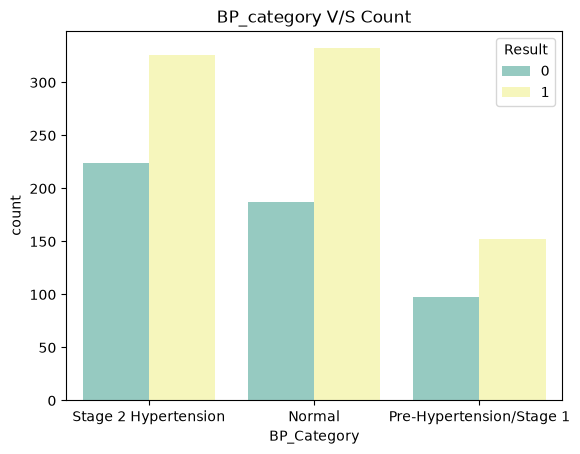

In [17]:
sns.countplot(x=data['BP_Category'],hue=data['Result'],palette='Set3')
plt.title("BP_category V/S Count")
plt.show()

[]

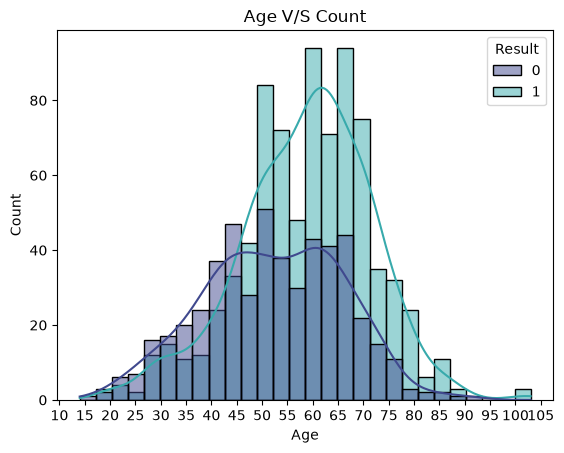

In [18]:
sns.histplot(data=data,x='Age',hue='Result',palette='mako',kde=True)
plt.title("Age V/S Count")  
plt.xticks(np.arange(10,111,5))
plt.plot()

In [19]:
data["Result"].groupby(data["Age"]).value_counts()
pd.crosstab(data['Result'],data['Age'])

Age,14,19,20,21,22,23,24,25,26,27,...,83,84,85,86,87,88,90,91,100,103
Result,,,,,,,,,,,,,,,,,,,,,
0,1,1,1,2,3,1,2,3,2,3,...,1,0,1,1,0,0,1,1,0,0
1,0,2,1,3,0,1,0,1,1,3,...,1,1,4,4,2,1,2,0,1,2


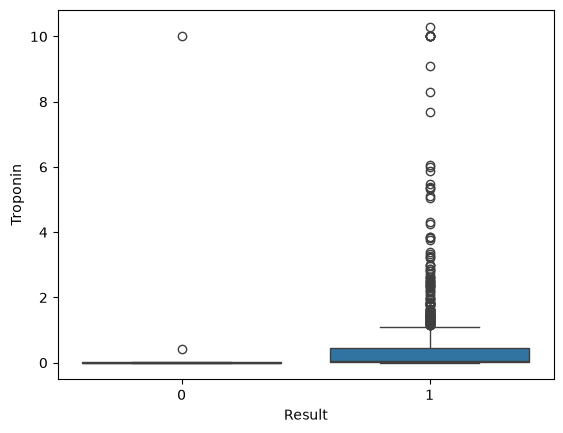

In [20]:
sns.boxplot(data=data,x='Result',y='Troponin')
plt.show()

##### Winsorization(capping) for outlier mitigation
Winsorization (named after the statistician Charles Winsor) is a technique used to handle extreme outliers in a dataset without actually deleting rows of data.Winsorization takes the extreme values that fall outside a specific boundary (like the $99^{\text{th}}$ percentile) and forcibly sets them to that boundary value.

In [21]:
thresh_val=np.percentile(data['Troponin'],99)

In [22]:
data['Troponin']=np.where(data['Troponin']>thresh_val,thresh_val,data['Troponin'])

<Axes: xlabel='Result', ylabel='Troponin'>

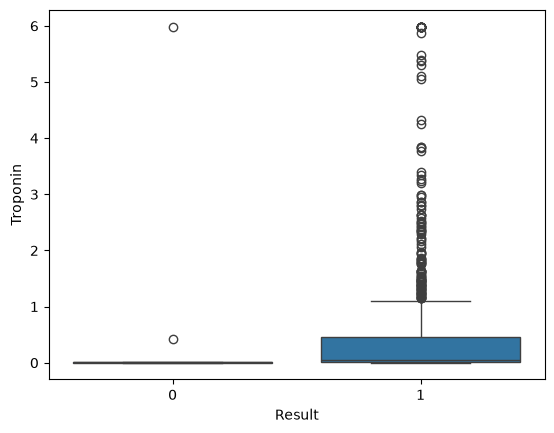

In [23]:
sns.boxplot(data=data,x='Result',y='Troponin')

Correlation Matrix

In [24]:
Intdata=data.iloc[0:1319,0:9]

<Axes: >

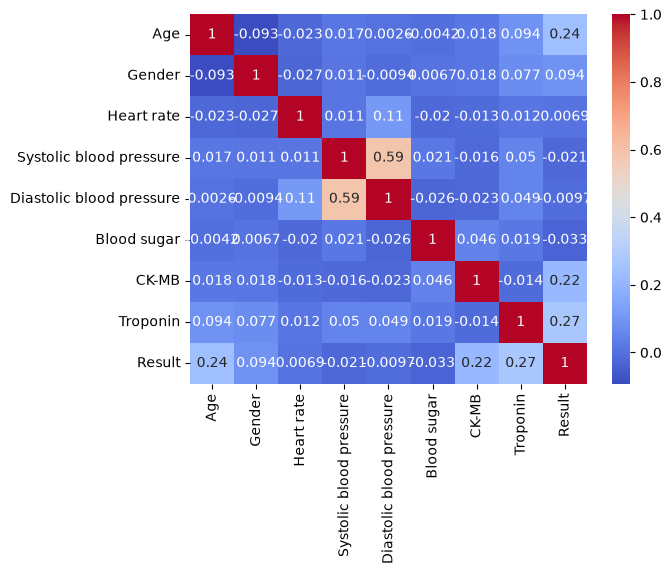

In [25]:
sns.heatmap(Intdata.corr(),annot=True,cmap='coolwarm')

Implementing Scikit-Learn

In [26]:
X=data[['Age','Troponin','CK-MB']] 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [28]:
y=data['Result']

In [29]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [30]:
print(X_train.shape)
print(X_test.shape)

(1055, 3)
(264, 3)


In [35]:
model=LogisticRegression()
model.fit(X_train,y_train)
print("Training Completed! Model is locked and loaded")

Training Completed! Model is locked and loaded


Running/Testing First Model

In [36]:
y_predict=model.predict(X_test)
print("Test Accuracy: ",accuracy_score(y_test,y_predict))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_predict))

Test Accuracy:  0.7992424242424242
Confusion Matrix:
 [[ 73  28]
 [ 25 138]]


Precision: Out of all the patients the model predicted were having a heart attack, how many were actually having one? (Low precision means too many false alarms).
$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}} = \frac{138}{138 + 28} \approx 0.8313 \text{ (or } 83.13\%)$$
Recall (Sensitivity): Out of all the patients who were actually having a heart attack, what percentage did the model successfully catch? (Low recall means you are letting dying patients slip through the cracks).
$$\text{Recall} = \frac{138}{138 + 25} \times 100 \approx 84.66\%$$